# Step 1 - Train the model (do this *before* the demo)

Run this once on the GPU box. It does three things:

1. downloads a few hundred real galaxy images from the SDSS public archive
2. trains a small neural network to reverse the blur-and-shrink process
3. saves the trained weights to `weights/galaxy_sr.pt`

Nothing here runs during the live demo. Budget ~10 minutes end to end, most
of which is the download, not the training.

**If the machine has no internet**, this still works - it falls back to
simulated galaxies built from the same equations astronomers use to model
real ones. The demo is just less pretty.

In [1]:
import torch
from galaxy_sr import data, viz
from galaxy_sr.train import train

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))

GPU available: True
device: NVIDIA GeForce RTX 5090


## Get the images

`build_dataset` caches everything to `data/` as PNGs, so re-running is cheap
and the demo notebook never needs the network.

In [2]:
# Downloads run 8 at a time and give up after `budget_min` minutes,
# topping up with simulated galaxies if the archive is slow or unreachable.
info = data.build_dataset("data", n_train=300, size=256, budget_min=8.0)
info

Already cached: 308 training + 20 demo images.


{'source': 'cache', 'n_train': 308, 'n_demo': 20}

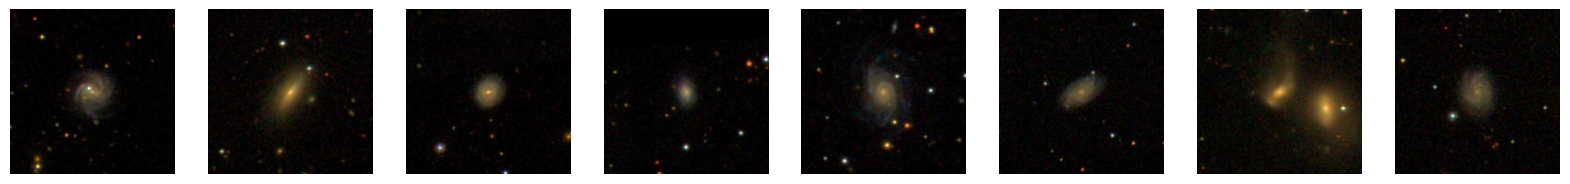

In [3]:
# quick look at what we got
import matplotlib.pyplot as plt
imgs = data.load_images("data/train")[:8]
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, im in zip(axes, imgs):
    ax.imshow(im); ax.axis("off")
plt.show()

## Train

Well under a minute on a recent GPU at these settings; ten to fifteen on a
free Colab one. Raise `steps` if you have time, though the gap over the
non-AI baseline mostly stops widening after a few thousand.

Set `wandb_project=` if you want the run tracked in Weights & Biases (loss
curve, held-out scores, and the checkpoint saved as an artifact). It is off
by default so that this works without an account.

In [4]:
info = train(
    data_dir="data/train",
    out="weights/galaxy_sr.pt",
    steps=6000,       # the loss curve flattens well before this
    batch=16,
    patch=128,
    channels=64,
    blocks=12,
    factor=4,         # 4x upscaling
    sigma=2.8,        # how badly the "small telescope" blurs
    noise=0.05,       # how noisy its detector is
    # wandb_project="galaxy-ai-demo",   # optional experiment tracking
)

308 training images | device: cuda
model has 1,222,147 trainable numbers
  step     1/6000  loss 0.0420  (0s)
  step   100/6000  loss 0.0210  (1s)
  step   200/6000  loss 0.0173  (2s)
  step   300/6000  loss 0.0163  (2s)
  step   400/6000  loss 0.0140  (3s)
  step   500/6000  loss 0.0166  (3s)
  step   600/6000  loss 0.0160  (4s)
  step   700/6000  loss 0.0158  (4s)
  step   800/6000  loss 0.0135  (5s)
  step   900/6000  loss 0.0156  (6s)
  step  1000/6000  loss 0.0153  (6s)
  step  1100/6000  loss 0.0156  (7s)
  step  1200/6000  loss 0.0152  (7s)
  step  1300/6000  loss 0.0148  (8s)
  step  1400/6000  loss 0.0157  (8s)
  step  1500/6000  loss 0.0158  (9s)
  step  1600/6000  loss 0.0146  (10s)
  step  1700/6000  loss 0.0146  (10s)
  step  1800/6000  loss 0.0156  (11s)
  step  1900/6000  loss 0.0149  (11s)
  step  2000/6000  loss 0.0169  (12s)
  step  2100/6000  loss 0.0148  (13s)
  step  2200/6000  loss 0.0139  (13s)
  step  2300/6000  loss 0.0148  (14s)
  step  2400/6000  loss 0.0151 

## Sanity check before the demo

Look at these. If the AI panel is not visibly better than the ordinary
enlargement, train for more steps before demo day.

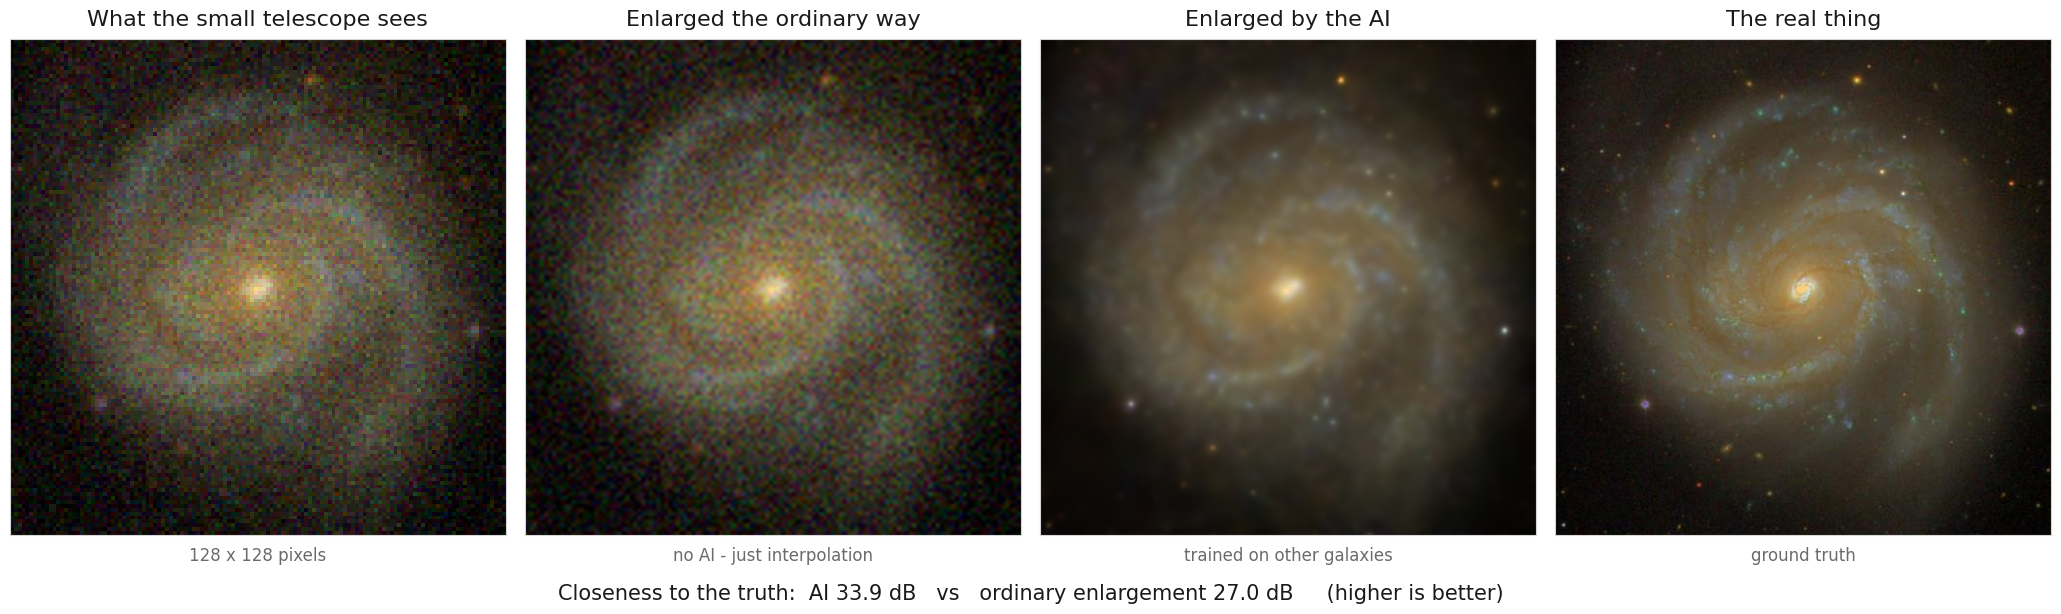

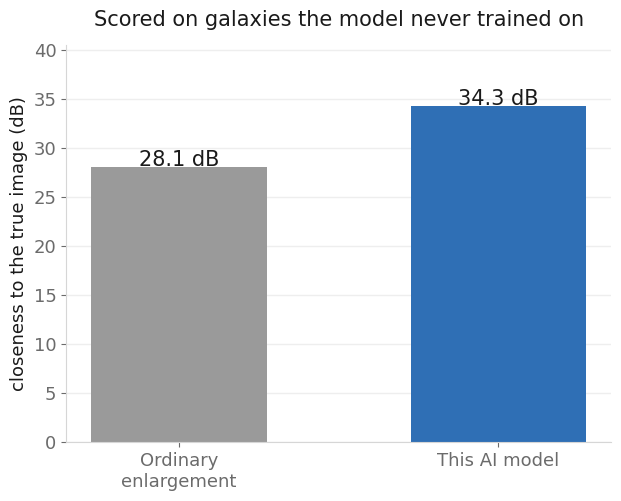

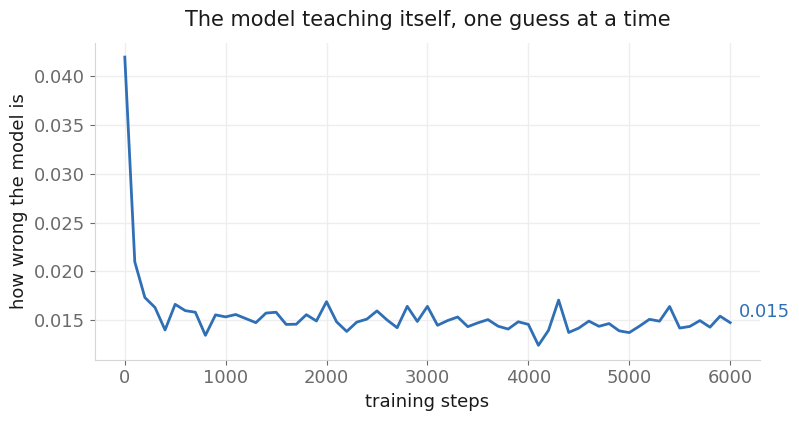

In [5]:
from galaxy_sr.model import load_trained

model, info = load_trained("weights/galaxy_sr.pt")
demo_imgs = data.load_images("data/demo")
res = viz.run_all(model, demo_imgs[0])

viz.compare(res, save="figures/check_compare.png")
viz.scoreboard(info, save="figures/check_score.png")
viz.learning_curve(info, save="figures/check_curve.png")
plt.show()

### Done

`weights/galaxy_sr.pt` is all the demo notebook needs. Open `02_demo.ipynb`
and run it once end-to-end today, so that tomorrow you are re-running
something you have already seen work.